# Run a workflow

In [1]:
import os
import shutil

from ewoks import execute_graph
from ewokscore.variable import value_from_transfer
from ewokscore.tests.utils.show import show_graph
from ewokscore.tests.examples.graphs import get_graph

## Select and configure a task scheduler

In [2]:
scheduler = None  # select any of the schedulers shown below

execute_options = dict()

if scheduler == "dask_multithreading":
    # tasks are distributed by a local scheduler over multiple threads
    execute_options["binding"] = "dask"
    execute_options["scheduler"] = "multithreading"
elif scheduler == "dask_multiprocessing":
    # tasks are distributed by a local scheduler over multiple processes
    execute_options["binding"] = "dask"
    execute_options["scheduler"] = "multiprocessing"
elif scheduler == "dask_local_cluster":
    # tasks are distributed by a local scheduler
    execute_options["binding"] = "dask"
    execute_options["scheduler"] = "cluster"
elif scheduler == "dask_remote_cluster":
    # tasks are distributed by a remote scheduler
    execute_options["binding"] = "dask"
    execute_options["scheduler"] = "127.0.0.1:40331"

    # There are different ways to start a remote scheduler
    #
    # Start a dask scheduler on any host:
    #  >>> from ewoksdask.schedulers import local_scheduler
    #  >>> scheduler = local_scheduler(n_workers=5)
    #
    # Start a dask scheduler on a host that can launch slurm jobs:
    #  >>> from ewoksdask.schedulers import slurm_scheduler
    #  >>> scheduler = slurm_scheduler(maximum_jobs=5)

elif scheduler == "pypushflow":
    # tasks are distributed by a local scheduler over multiple processes
    execute_options["binding"] = "ppf"
else:
    # tasks are executed in a single thread
    scheduler = None
    pass

## Select a task graph

{'directed': True,
 'graph': {'id': 'acyclic1', 'label': 'acyclic1'},
 'links': [{'data_mapping': [{'source_output': 'result', 'target_input': 'a'}],
            'source': 'task1',
            'target': 'task3'},
           {'data_mapping': [{'source_output': 'result', 'target_input': 'a'}],
            'source': 'task2',
            'target': 'task4'},
           {'data_mapping': [{'source_output': 'result', 'target_input': 'a'}],
            'source': 'task3',
            'target': 'task5'},
           {'data_mapping': [{'source_output': 'result', 'target_input': 'b'}],
            'source': 'task4',
            'target': 'task5'},
           {'data_mapping': [{'source_output': 'result', 'target_input': 'a'}],
            'source': 'task5',
            'target': 'task6'}],
 'multigraph': False,
 'nodes': [{'default_inputs': [{'name': 'a', 'value': 1}],
            'id': 'task1',
            'task_identifier': 'ewokscore.tests.examples.tasks.sumtask.SumTask',
            'task_type': 

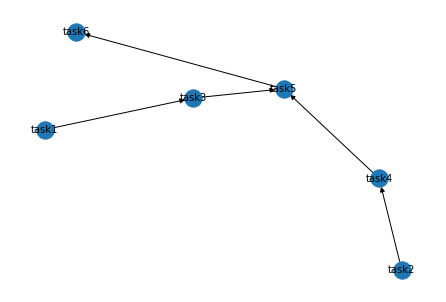

In [3]:
taskgraph, expected_results = get_graph("acyclic1")
show_graph(taskgraph)

## Configure storage of results (if any)

In [4]:
def prepare_storage(clean=True):
    if not varinfo["root_uri"]:
        return  # results are not persisted by ewoks
    if clean:
        shutil.rmtree(varinfo["root_uri"], ignore_errors=True)
    os.makedirs(varinfo["root_uri"], exist_ok=True)


varinfo = {"root_uri": None}  # folder where all results will be saved
execute_options["varinfo"] = varinfo
prepare_storage(clean=True)

## Execute the workflow

In [5]:
print("Execution options:")
print(execute_options)
results = execute_graph(taskgraph, **execute_options)

Execution options:
{'varinfo': {'root_uri': None}}


## Inspect results

In [6]:
print("\nResults:")
if scheduler is None:
    for task_name, task in sorted(results.items()):
        for name, result in task.output_values.items():
            print(f" {task_name} {name}:", result)
elif scheduler == "pypushflow":
    for name, result in results.items():
        if name == "_noinput":
            continue
        value = value_from_transfer(result, varinfo=varinfo)
        print(f" {name}:", value)
else:
    for task_name, task in sorted(results.items()):
        for name, result in task.items():
            value = value_from_transfer(result, varinfo=varinfo)
            print(f" {task_name} {name}:", value)


Results:
 task6 result: 16
